# 05 — Side-by-side comparison

This notebook does not introduce a new method. It re-imports the four distance
functions from `utils/distances.py` — the finished versions of the algorithms derived
step by step in notebooks 01-04 — and applies all of them to the same
`reference -> variant` pairs, so the differences in behaviour become visible in one
table and one chart.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data.synthetic import generate_dataset
from utils import plotting
from utils.distances import (
    dtw_distance, edr_distance, erp_distance, feature_distances,
    dtw_cost_matrix, dtw_path,
    edr_cost_matrix, edr_path,
    erp_cost_matrix, erp_path,
)

%matplotlib inline
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

In [2]:
dataset = generate_dataset()
reference = dataset["reference"]
variants = [name for name in dataset if name != "reference"]

# Parameters of the two parameterised methods, as chosen in notebooks 02 and 03.
EPS = 0.5  # EDR matching tolerance
G = 0.0    # ERP gap element

In [3]:
# One row per variant, one column per method. This takes a few seconds:
# three O(n*m) DP matrices per variant, in plain Python loops.
feature_dist = feature_distances(dataset)

comparison = pd.DataFrame({
    "DTW": [dtw_distance(reference, dataset[v]) for v in variants],
    "EDR": [edr_distance(reference, dataset[v], EPS) for v in variants],
    "ERP": [erp_distance(reference, dataset[v], G) for v in variants],
    "feature_distance": [feature_dist[v] for v in variants],
}, index=variants)
comparison.index.name = "variant"
comparison

,DTW,EDR,ERP,feature_distance
variant,,,,
amplitude_scaled,273.333,222.000,393.901,5.978
resampled,23.310,90.000,120.185,1.399
noisy,122.133,107.000,124.208,5.802
phase_shifted,83.347,80.000,130.045,1.285
reversed,100.358,146.000,187.117,0.000
unrelated,317.349,240.000,340.040,5.398


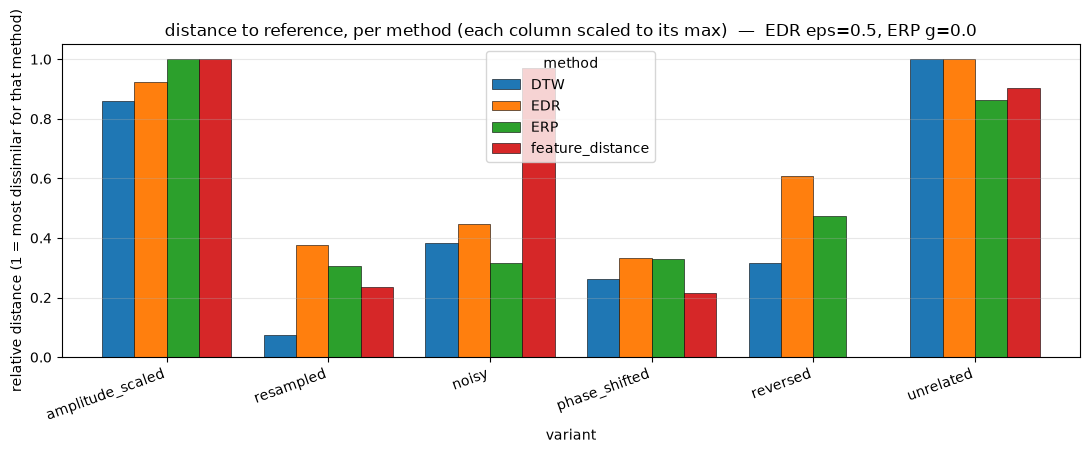

In [4]:
# The four columns live on completely different scales (edit counts vs. summed
# magnitudes vs. a z-score distance), so scale each column to its own maximum
# before plotting. Only the *shape* of each group is meaningful, not the height.
scaled = comparison / comparison.max()
plotting.plot_distance_bars(
    scaled,
    title=f"distance to reference, per method (each column scaled to its max)"
          f"  —  EDR eps={EPS}, ERP g={G}",
    ylabel="relative distance (1 = most dissimilar for that method)",
)

In [5]:
# Ranks make the disagreements easier to read than the raw numbers:
# 1 = most similar to the reference, 6 = most dissimilar, per method.
ranks = comparison.rank().astype(int)
ranks

,DTW,EDR,ERP,feature_distance
variant,,,,
amplitude_scaled,5,5,6,6
resampled,1,2,1,3
noisy,4,3,2,5
phase_shifted,2,1,3,2
reversed,3,4,4,1
unrelated,6,6,5,4


## The same pair, three cost surfaces

The table above says *how far apart* the methods rank the variants. It cannot show
*why*. Notebooks 01-03 each plot a cost matrix, but each one uses a different pair, so
the three pictures are not directly comparable.

Below, all three DP methods are run on the **same** pair, with the same colour scheme
and the same axes, so every visible difference is a difference in the algorithm. Read
the colour as "cost of aligning the first `i` samples of the reference with the first
`j` samples of the variant", and the red line as the alignment the method chose.

Two pairs are shown, because one is not enough to tell the story:

- **`resampled`** — a clean 1.3x stretch. All three methods recover the same warping,
  so this pair isolates the difference between the three *cost surfaces*.
- **`phase_shifted`** — a constant 40-sample offset. Here the three *paths* themselves
  come apart, and the two mechanisms for absorbing a time shift become visible.

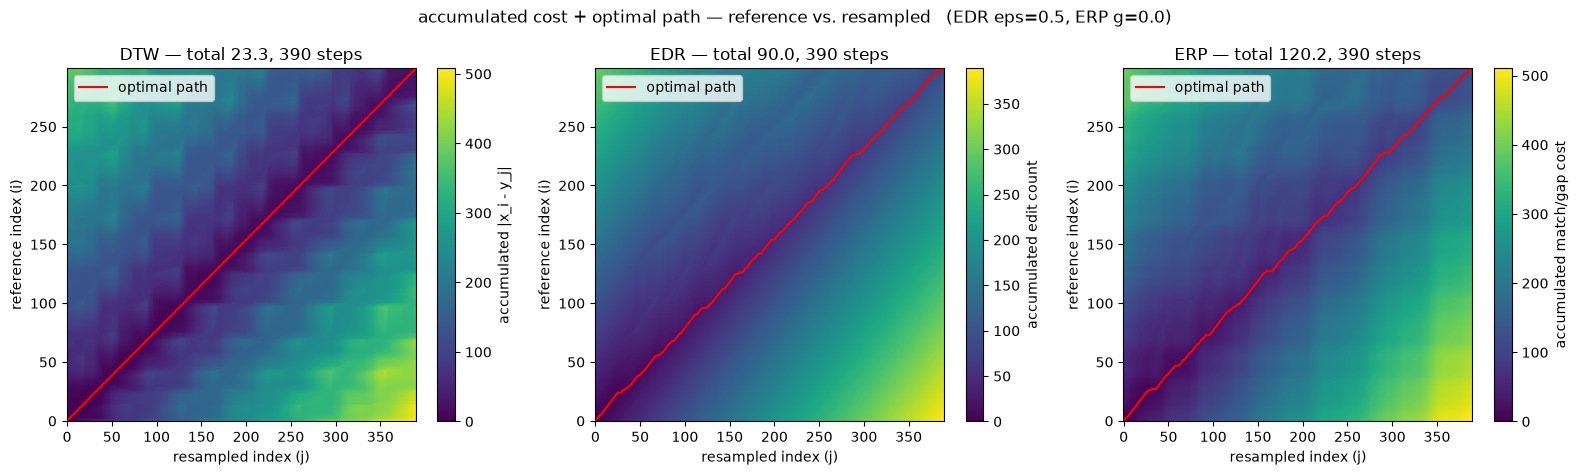

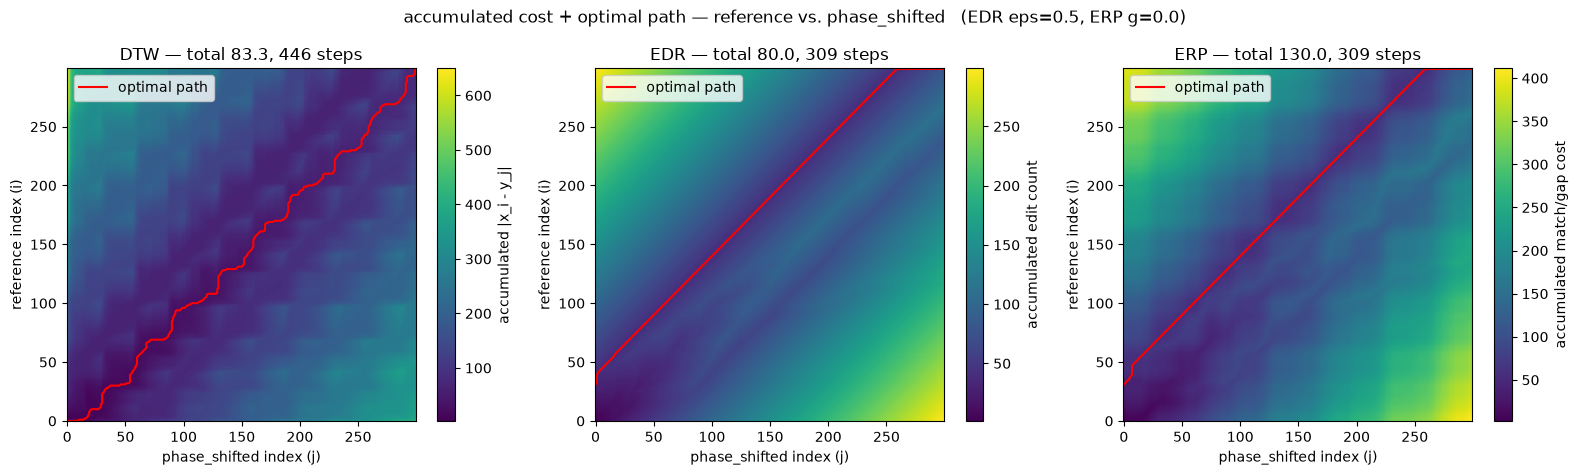

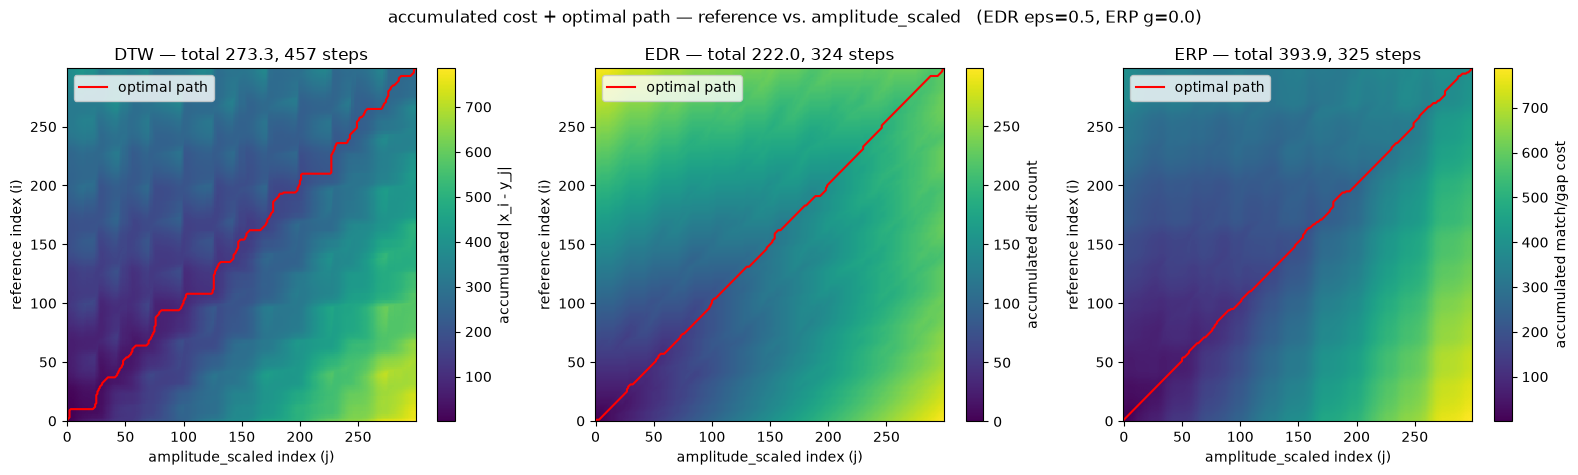

In [ ]:
def compare_cost_surfaces(variant: str) -> None:
    """Draw the DTW / EDR / ERP cost matrix of `reference` vs. `variant` side by side.

    Same pair, same colour scheme, same axes — only the method changes, so any
    difference in the picture is a difference in the algorithm.
    """
    other = dataset[variant]
    methods = [
        ("DTW", dtw_cost_matrix(reference, other), dtw_path, "accumulated |x_i - y_j|"),
        ("EDR", edr_cost_matrix(reference, other, EPS), edr_path, "accumulated edit count"),
        ("ERP", erp_cost_matrix(reference, other, G), erp_path, "accumulated match/gap cost"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    for ax, (label, D, backtrack, cbar) in zip(axes, methods):
        path = backtrack(D)
        plotting.plot_cost_matrix(
            D[1:, 1:],  # drop the padding border for plotting
            path=path,
            title=f"{label} — total {D[-1, -1]:,.1f}, {len(path)} steps",
            xlabel=f"{variant} index (j)",
            ylabel="reference index (i)",
            cbar_label=cbar,
            ax=ax,
        )
    fig.suptitle(f"accumulated cost + optimal path — reference vs. {variant}"
                 f"   (EDR eps={EPS}, ERP g={G})")
    fig.tight_layout()
    plt.show()


# Two pairs: one where all three agree, one where they visibly do not.
compare_cost_surfaces("resampled")
compare_cost_surfaces("phase_shifted")

### What the two figures show

**`resampled`: identical paths, different surfaces.** All three methods return a path of
390 steps with exactly the same composition (77 % diagonal, 23 % horizontal, no vertical
moves) — they all recover the 1.3x stretch, and the three red lines are effectively the
same line. What differs is the landscape underneath it. DTW's surface carries a fine
periodic texture from the 1.0 Hz and 2.5 Hz components and has a narrow, sharply defined
valley: its path never strays more than **0.6** samples from the ideal straight line.
EDR's and ERP's valleys are much broader and smoother, and their paths wander up to
**7** samples off it. A broad valley means many alignments cost nearly the same, so the
back-tracking tie-break decides between them — the optimum is real, but it is flat.
ERP additionally shows vertical banding, where the gap term `|y_j - g|` is large.

**`phase_shifted`: the paths come apart.** This is the interesting one, and the reason
one pair is not enough. EDR and ERP find the true alignment: their paths start at
**(31, 0)** — not in the corner — and then hold an offset of exactly **40** samples, the
`SHIFT` constant from `data/synthetic.py`. DTW never finds it. It is pinned to the
corner, wanders with an offset between −21 and 0, and burns 446 steps (only 34 %
diagonal) doing it.

**Why — and it is visible in the border, not the interior.** DTW initialises its cost
matrix with `D[0, 0] = 0` and `inf` everywhere else on the border, so the path is
*forced* to run corner to corner: every one of the 40 samples of offset has to be paid
as a warping move at full magnitude. EDR and ERP initialise their borders with a finite
cumulative cost (`np.arange` and `np.cumsum(gap)` respectively), so the path may
terminate *on* the border — consuming a prefix of the reference as pure gaps for a flat
cost of 1 each (EDR) or `|x_i - g|` each (ERP), then running clean and parallel to the
diagonal.

That is a structural difference between the algorithms that the distance table cannot
show: DTW's 83.3 and EDR's 80.0 look like near-agreement, but the two numbers are
reached by completely different alignments — and only one of them is the correct one.

## What the chart shows

**Where all four agree.** `resampled` and `phase_shifted` are the two most similar
variants for every method. The three DP methods get there by warping the time axis; the
feature approach gets there because summary statistics barely change when a signal is
stretched or shifted. `unrelated` and `amplitude_scaled` sit at the dissimilar end
everywhere — though for different reasons, and in a different order: ERP punishes the
doubled amplitude hardest of all (rank 6, ahead of `unrelated`), because it pays real
magnitudes for matches *and* gaps, while DTW has the two nearly tied and EDR keeps the
amplitude change bounded by its flat cost of 1 per mismatch.

**Where they disagree — `reversed`.** This is the clearest split in the table. DTW, EDR
and ERP all separate it from the reference by a wide margin (100.4 / 146 / 187.1, three
to six times the `resampled` cost), because their monotone alignment paths cannot map a
rising ramp onto a falling one. The feature approach gives it a distance of **exactly
0**: all twelve features (moments, zero-crossing rate, FFT magnitudes, autocorrelation)
are invariant under time reversal, so the two series are literally the same point in
feature space — it is ranked the *most similar* variant of all.

**Where they disagree — `noisy`.** The feature approach ranks `noisy` as *more*
dissimilar than the structurally `unrelated` step signal, because additive noise moves
kurtosis, zero-crossing rate and the autocorrelation coefficients a long way, while the
step signal happens to land near the reference on several of those features. All three
DP methods rank it the other way round.

**Practical reading.** Use DTW when speed differences matter and magnitudes should be
compared honestly; EDR when the data is spiky and a tolerance band is a natural notion of
"equal" (but budget time for tuning `eps`); ERP when you need a real metric for indexing
or clustering; and features when you have many long series and need something cheap,
cacheable and classifier-ready — provided the properties you care about actually survive
the summarisation.